# BioSense360 — Pipeline de Prédiction de la Vivabilité Environnementale

---

## Informations du Projet

| Élément | Détail |
|---------|--------|
| **Projet** | BioSense360 — Système de prédiction de vivabilité thermique basé sur les capteurs Neusta |
| **Client** | Damien APPERT — Neusta |
| **Équipe** | Nourhane MALLEK (Cheffe de projet & IA), Soufiane KHALLOUKI (Data), Daniil ZHDANOV (Visualisation) |
| **Date** | Mars 2026 |
| **Version** | v3.0 — Pipeline IA complet, validé sur données capteurs réels |

---

## Contexte Scientifique

Les capteurs **ClimaTrack** de Neusta collectent en continu des données de **température** et d'**humidité**.  
L'objectif est de transformer ces mesures brutes en **informations de sécurité exploitables** pour déterminer  
si un lieu est vivable ou dangereux pour les humains.

### Pourquoi la Température et l'Humidité ?

Notre état de l'art (Mallek, Khallouki, Zhdanov, 2026) a démontré que :

1. Le modèle classique **PMV** (Predicted Mean Vote, ISO 7730) exige 6 variables dont certaines  
   sont impossibles à mesurer en extérieur à grande échelle (isolation vestimentaire `clo`, métabolisme `met`, température radiante `MRT`).
2. Les capteurs Neusta (**ClimaTrack**) ne fournissent de manière fiable et systématique que la **température** et l'**humidité relative**.
3. L'indice **Humidex** — retenu comme métrique centrale — se calcule uniquement à partir de ces deux variables.
4. Le **Random Forest** surpasse le PMV en précision (76.7% vs 35.4%, Farhan et al.) même avec un nombre restreint de features.

### L'Humidex comme Variable Cible

L'Humidex (Masterton & Richardson, 1979) combine température et humidité pour exprimer  
une **température ressentie équivalente** en °C :

$$HX = T_a + \frac{5}{9}(e - 10)$$

où $e = 6.112 \times 10^{\frac{7.5 \times T_a}{237.7 + T_a}} \times \frac{RH}{100}$

Les **seuils critiques** (Alfano et al., 2010 ; Diaconescu et al., 2022) définissent les classes de danger  
qui structurent notre système d'alarme à 8 niveaux.

---

## Architecture du Pipeline

Ce notebook couvre les **features fonctionnelles du Cahier des Charges** :

| Section | Feature CDC | Description |
|---------|-------------|-------------|
| **Partie 1** | F1 | Acquérir et préparer les données environnementales |
| **Partie 2** | F2 | Prédire les variables environnementales (entraînement & évaluation IA) |
| **Partie 3** | F3 | Détecter les dangers de l'environnement |
| **Partie 4** | F4 | Recommander des actions pour les humains |
| **Partie 5** | F6 | Visualiser les résultats |
| **Partie 6** | — | Validation croisée sur données Neusta |

---
## Imports et Configuration Globale

Chargement des bibliothèques standard du projet :
- **pandas / numpy** : manipulation et vectorisation des données
- **scikit-learn** : entraînement, évaluation et export des modèles
- **matplotlib / seaborn** : visualisations scientifiques
- **joblib** : sérialisation du modèle pour la production


In [5]:
# =============================================================================
# IMPORTS ET CONFIGURATION
# =============================================================================
# Manipulation de données
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import StandardScaler

# Utilitaires
import warnings
warnings.filterwarnings('ignore')

# Configuration graphique
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

# Graine aléatoire pour la reproductibilité
RANDOM_STATE = 42

print("Environnement chargé avec succès.")

# =============================================================================
# CHEMINS DES DONNEES
# =============================================================================
PATH_METEO  = '../Data/meteo_France_data/data202425_meteo_france.csv'
PATH_NEUSTA = '../Data/Neusta/donnees_neusta.csv'
EXPORT_MODEL_DIR = '../production/models'


Environnement chargé avec succès.


---
# PARTIE 1 — Acquérir et Préparer les Données (F1)

**Objectif CDC :**  
- F1-UC1 : Importer les fichiers bruts  
- F1-UC2 : Convertir et formater en CSV standardisé  
- F1-UC3 : Nettoyer, imputer, normaliser et agréger les données  

### Sources de données

| Source | Rôle | Période | Volume | Variables clés |
|--------|------|---------|--------|----------------|
| **Météo France** (data.gouv.fr) | Entraînement | 2024-2025 | ~468 570 obs. | `Temp_C`, `u`, `Humidex`, `Vivabilite` |
| **Capteurs Neusta** (ClimaTrack) | Test / Validation | Jan–Déc 2024 | ~395 000 obs. | `Temperature`, `Humidity`, `Humidex`, `Vivabilite` |

## 1.1 — Chargement des données brutes (F1-UC1)

Importation des deux sources de données historiques :
- **Météo France** (`data202425.csv`) : données synoptiques nationales 2024–2025, utilisées pour l’entraînement du modèle.
- **Neusta ClimaTrack** (`donnees_neusta.csv`) : mesures IoT de capteurs physiques, réservées exclusivement à la validation finale.

> Ces deux sources sont intentionnellement séparées pour garantir qu’aucune donnée capteur ne contamine l’entraînement.


In [ ]:
# F1-UC1 
# Ce fichier a été constitué en fusionnant les données synoptiques de Météo France
# pour 2024 et 2025, récupérées via l'API de data.gouv.fr.
# Rapport de référence : Khallouki S. (2026), "Exploration et préparation des données
# météorologiques Météo-France 2024-2025", Rapport interne BioSense360.

df_meteo = pd.read_csv(PATH_METEO)

print(f"Dataset Météo France chargé : {df_meteo.shape[0]:,} lignes × {df_meteo.shape[1]} colonnes")
print(f"\nColonnes disponibles ({len(df_meteo.columns)}) :")
print(df_meteo.columns.tolist())

Dataset Météo France chargé : 468,570 lignes × 69 colonnes

Colonnes disponibles (69) :
['lat', 'lon', 'geo_id_wmo', 'geo_id_wigos', 'name', 'reference_time', 'insert_time', 'validity_time', 'pmer', 'tend', 'cod_tend', 'dd', 'ff', 't', 'td', 'u', 'vv', 'ww', 'w1', 'w2', 'n', 'nbas', 'hbas', 'cl', 'cm', 'ch', 'pres', 'niv_bar', 'geop', 'tend24', 'tn12', 'tn24', 'tx12', 'tx24', 'tminsol', 'sw', 'tw', 'raf10', 'rafper', 'per', 'etat_sol', 'ht_neige', 'ssfrai', 'perssfrai', 'rr1', 'rr3', 'rr6', 'rr12', 'rr24', 'phenspe1', 'phenspe2', 'phenspe3', 'phenspe4', 'nnuage1', 'ctype1', 'hnuage1', 'nnuage2', 'ctype2', 'hnuage2', 'nnuage3', 'ctype3', 'hnuage3', 'nnuage4', 'ctype4', 'hnuage4', 'Temp_C', 'Dew_C', 'humidex', 'Vivabilite']


In [ ]:
# F1-UC1 : CHARGEMENT DU DATASET NEUSTA (VALIDATION)
# Données issues des capteurs ClimaTrack déployés par Neusta.
# Fréquence d'échantillonnage : ~10 secondes (capteur principal),
# ~3 minutes (capteur secondaire pour ~6800 observations).
# Période : 10 janvier 2024 — 11 décembre 2024.

df_neusta = pd.read_csv(PATH_NEUSTA)

print(f"Dataset Neusta chargé : {df_neusta.shape[0]:,} lignes × {df_neusta.shape[1]} colonnes")
print(f"\nColonnes : {df_neusta.columns.tolist()}")
print(f"\nPériode : {df_neusta['timestamp'].min()} → {df_neusta['timestamp'].max()}")

Dataset Neusta chargé : 395,039 lignes × 16 colonnes

Colonnes : ['timestamp', 'Temperature', 'Humidity', '22.57', '22.56', '22.58', '22.54', '22.53', '22.51', 'temperature', 'humidity', 'PM1', 'PM2.5', 'PM10', 'Humidex', 'Vivabilite']

Période : 2024-01-10 00:00:02 → 2024-12-11 23:59:54


## 1.2 — Sélection et standardisation des colonnes (F1-UC2)

Les deux datasets utilisent des conventions de nommage différentes (majuscules, unités, suffixes).
Standardisation vers le schéma commun du projet :

| Colonne cible | Source Météo France | Source Neusta ClimaTrack |
|---------------|---------------------|-------------------------|
|  |  (float, °C) |  (float, °C) |
|  |  (float, %) |  (float, %) |
|  | calculé en aval | calculé en aval |
|  | calculée via classe Humidex | calculée via classe Humidex |

Les colonnes non pertinentes pour le modèle (pression, vent, station, etc.) sont écartées.


In [ ]:
# F1-UC2 : STANDARDISATION DU DATASET MÉTÉO FRANCE

# On ne conserve que les colonnes pertinentes pour nos modèles :
# - Temp_C : Température de l'air en °C (convertie depuis Kelvin dans le pipeline précédent)
# - u : Humidité relative en %
# - humidex : Indice Humidex calculé (Masterton & Richardson, 1979)
# - Vivabilite : Classe de danger (0-7) basée sur les seuils Humidex
# - Métadonnées géographiques et temporelles pour la traçabilité

COLONNES_METEO = {
    'validity_time': 'datetime',
    'name': 'station',
    'lat': 'latitude',
    'lon': 'longitude',
    'Temp_C': 'temperature',
    'u': 'humidite',
    'humidex': 'humidex',
    'Vivabilite': 'vivabilite'
}

# Sélection et renommage
colonnes_existantes = [c for c in COLONNES_METEO.keys() if c in df_meteo.columns]
df_meteo_std = df_meteo[colonnes_existantes].rename(columns=COLONNES_METEO)

# Conversion des types
df_meteo_std['temperature'] = pd.to_numeric(df_meteo_std['temperature'], errors='coerce')
df_meteo_std['humidite'] = pd.to_numeric(df_meteo_std['humidite'], errors='coerce')
df_meteo_std['humidex'] = pd.to_numeric(df_meteo_std['humidex'], errors='coerce')
df_meteo_std['vivabilite'] = pd.to_numeric(df_meteo_std['vivabilite'], errors='coerce')

print(f"Météo France standardisé : {df_meteo_std.shape}")
print(f"\nAperçu :")
df_meteo_std.head()

Météo France standardisé : (468570, 8)

Aperçu :


,datetime,station,latitude,longitude,temperature,humidite,humidex,vivabilite
0,2024-01-01T00:00:00Z,ABBEVILLE,50.136000,1.834000,7.4,81.0,7.400000,0.0
1,2024-01-01T00:00:00Z,AJACCIO,41.918000,8.792667,13.1,84.0,14.612672,0.0
2,2024-01-01T00:00:00Z,BASTIA,42.540667,9.485167,9.2,81.0,9.200000,0.0
3,2024-01-01T00:00:00Z,PLOUMANAC'H,48.825833,-3.473167,9.8,72.0,9.800000,0.0
4,2024-01-01T00:00:00Z,GLORIEUSES,-11.582667,47.289667,26.4,92.0,38.738410,4.0


In [ ]:
# F1-UC2 : STANDARDISATION DU DATASET NEUSTA

# Le CSV Neusta contient des colonnes parasites (artefacts capteurs : '22.57', '22.56', etc.)
# et deux jeux de colonnes température/humidité :
#   - 'Temperature' / 'Humidity' (capteur principal, ~388k valeurs)
#   - 'temperature' / 'humidity' (capteur secondaire, ~6800 valeurs)
# On utilise le capteur principal et on ignore les colonnes parasites.

COLONNES_NEUSTA = {
    'timestamp': 'datetime',
    'Temperature': 'temperature',
    'Humidity': 'humidite',
    'Humidex': 'humidex',
    'Vivabilite': 'vivabilite'
}

colonnes_existantes_n = [c for c in COLONNES_NEUSTA.keys() if c in df_neusta.columns]
df_neusta_std = df_neusta[colonnes_existantes_n].rename(columns=COLONNES_NEUSTA)

# Conversion des types
df_neusta_std['temperature'] = pd.to_numeric(df_neusta_std['temperature'], errors='coerce')
df_neusta_std['humidite'] = pd.to_numeric(df_neusta_std['humidite'], errors='coerce')
df_neusta_std['humidex'] = pd.to_numeric(df_neusta_std['humidex'], errors='coerce')
df_neusta_std['vivabilite'] = pd.to_numeric(df_neusta_std['vivabilite'], errors='coerce')

print(f"Neusta standardisé : {df_neusta_std.shape}")
print(f"\nAperçu :")
df_neusta_std.head()

Neusta standardisé : (395039, 5)

Aperçu :


,datetime,temperature,humidite,humidex,vivabilite
0,2024-01-10 00:00:02,20.17,59.97,22.475,0.0
1,2024-01-10 00:00:12,20.16,59.98,22.462,0.0
2,2024-01-10 00:00:22,20.16,59.94,22.457,0.0
3,2024-01-10 00:00:32,20.15,59.96,22.444,0.0
4,2024-01-10 00:00:42,20.15,60.00,22.450,0.0


## 1.3 — Nettoyage, audit qualité et imputation (F1-UC3)

Conformément au rapport d’analyse Météo France (Khallouki, 2026), les données présentent
des valeurs manquantes et des anomalies de capteurs. La stratégie adoptée :

1. **Audit préalable** : statistiques descriptives, taux de valeurs manquantes, doublons.
2. **Suppression** des lignes dont  ou  est absent (valeurs structurellement manquantes).
3. **Aucune imputation** : les données manquantes restantes sont retirées pour ne pas biaiser l’entraînement du modèle.
4. **Analyse de distribution** et de corrélation pour valider la qualité du jeu nettoyé.


In [ ]:
# F1-UC3 : AUDIT QUALITÉ DES DONNÉES

def audit_qualite(df, nom_dataset):
    """Réalise un audit qualité complet d'un DataFrame.
    
    Paramètres
    ----------
    df : pd.DataFrame
        Le jeu de données à auditer.
    nom_dataset : str
        Nom affiché dans le rapport.
    
    Retourne
    --------
    pd.DataFrame
        Tableau récapitulatif des valeurs manquantes.
    """
    print(f"{'='*60}")
    print(f"AUDIT QUALITÉ : {nom_dataset}")
    print(f"{'='*60}")
    print(f"Dimensions : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
    print(f"Doublons   : {df.duplicated().sum():,} lignes")
    
    # Bilan des valeurs manquantes
    nulls = df.isnull().sum()
    pct = (nulls / len(df) * 100).round(2)
    bilan = pd.DataFrame({'Manquantes': nulls, 'Pourcentage (%)': pct})
    bilan = bilan[bilan['Manquantes'] > 0].sort_values('Pourcentage (%)', ascending=False)
    
    if bilan.empty:
        print("\nAucune valeur manquante détectée.")
    else:
        print(f"\nValeurs manquantes :")
        print(bilan.to_string())
    
    # Statistiques descriptives des variables numériques clés
    cols_num = [c for c in ['temperature', 'humidite', 'humidex', 'vivabilite'] if c in df.columns]
    if cols_num:
        print(f"\nStatistiques descriptives :")
        print(df[cols_num].describe().round(2).to_string())
    
    return bilan

# Audit du dataset Météo France
bilan_meteo = audit_qualite(df_meteo_std, "Météo France")
print()
# Audit du dataset Neusta
bilan_neusta = audit_qualite(df_neusta_std, "Neusta (Capteurs)")

AUDIT QUALITÉ : Météo France
Dimensions : 468,570 lignes × 8 colonnes
Doublons   : 9,249 lignes

Valeurs manquantes :
             Manquantes  Pourcentage (%)
humidex            7229             1.54
vivabilite         7229             1.54
humidite           5669             1.21
temperature        3562             0.76

Statistiques descriptives :
       temperature   humidite    humidex  vivabilite
count    465008.00  462901.00  461341.00   461341.00
mean         15.18      77.96      18.25        0.81
std           9.06      16.09      12.38        1.54
min         -30.00       1.00     -30.00        0.00
25%           9.00      68.00       9.19        0.00
50%          14.40      81.00      16.02        0.00
75%          22.60      91.00      26.92        1.00
max          40.90     100.00      56.21        7.00

AUDIT QUALITÉ : Neusta (Capteurs)
Dimensions : 395,039 lignes × 5 colonnes
Doublons   : 0 lignes

Valeurs manquantes :
             Manquantes  Pourcentage (%)
temperatur

In [ ]:
# F1-UC3 : NETTOYAGE ET SUPPRESSION DES DONNÉES INEXPLOITABLES
# Stratégie de nettoyage :
#   - Suppression des lignes où température, humidité OU vivabilité sont manquantes
#     (ces variables sont indispensables pour l'entraînement et l'évaluation)
#   - Pas d'imputation sur les features d'entrée pour ne pas introduire de biais
#     dans un modèle dont l'accuracy est critique pour la sécurité humaine (CDC F3)

COLONNES_ESSENTIELLES = ['temperature', 'humidite', 'vivabilite']

# --- Météo France ---
taille_avant_meteo = len(df_meteo_std)
df_meteo_clean = df_meteo_std.dropna(subset=COLONNES_ESSENTIELLES).copy()
taille_apres_meteo = len(df_meteo_clean)
print(f"Météo France : {taille_avant_meteo:,} → {taille_apres_meteo:,} lignes ({taille_avant_meteo - taille_apres_meteo:,} supprimées, soit {(taille_avant_meteo - taille_apres_meteo)/taille_avant_meteo*100:.2f}%)")

# --- Neusta ---
taille_avant_neusta = len(df_neusta_std)
df_neusta_clean = df_neusta_std.dropna(subset=COLONNES_ESSENTIELLES).copy()
taille_apres_neusta = len(df_neusta_clean)
print(f"Neusta       : {taille_avant_neusta:,} → {taille_apres_neusta:,} lignes ({taille_avant_neusta - taille_apres_neusta:,} supprimées, soit {(taille_avant_neusta - taille_apres_neusta)/taille_avant_neusta*100:.2f}%)")

# Conversion de la cible en entier (classes discrètes)
df_meteo_clean['vivabilite'] = df_meteo_clean['vivabilite'].astype(int)
df_neusta_clean['vivabilite'] = df_neusta_clean['vivabilite'].astype(int)

Météo France : 468,570 → 461,341 lignes (7,229 supprimées, soit 1.54%)
Neusta       : 395,039 → 388,218 lignes (6,821 supprimées, soit 1.73%)


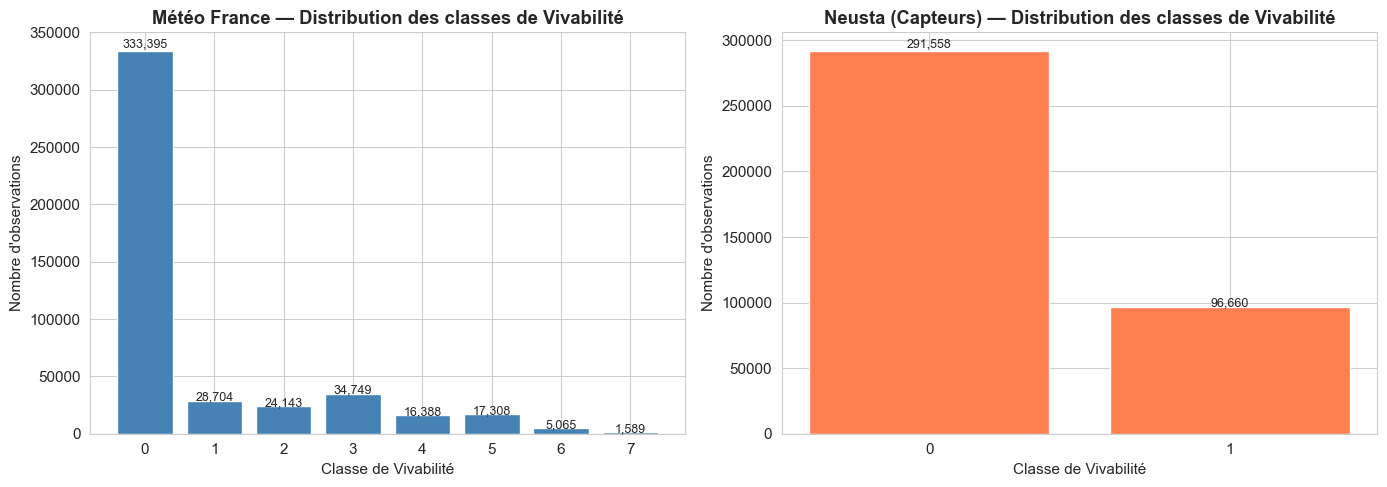


Météo France — Classes présentes : [0, 1, 2, 3, 4, 5, 6, 7]
Neusta       — Classes présentes : [0, 1]

Note : Les capteurs Neusta se trouvent dans un environnement intérieur/contrôlé,
ce qui explique que seules les classes 0 et 1 (Humidex < 30) sont observées.
Le modèle est néanmoins entraîné sur toute la gamme grâce aux données Météo France.


In [ ]:
# F1-UC3 : VISUALISATION DES DISTRIBUTIONS
# Objectif : comprendre la répartition des classes de vivabilité dans chaque dataset
# et identifier d'éventuels déséquilibres.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution Météo France
classes_meteo = df_meteo_clean['vivabilite'].value_counts().sort_index()
axes[0].bar(classes_meteo.index.astype(str), classes_meteo.values, color='steelblue', edgecolor='white')
axes[0].set_title('Météo France — Distribution des classes de Vivabilité', fontweight='bold')
axes[0].set_xlabel('Classe de Vivabilité')
axes[0].set_ylabel('Nombre d\'observations')
for i, v in enumerate(classes_meteo.values):
    axes[0].text(i, v + v*0.01, f'{v:,}', ha='center', fontsize=9)

# Distribution Neusta
classes_neusta = df_neusta_clean['vivabilite'].value_counts().sort_index()
axes[1].bar(classes_neusta.index.astype(str), classes_neusta.values, color='coral', edgecolor='white')
axes[1].set_title('Neusta (Capteurs) — Distribution des classes de Vivabilité', fontweight='bold')
axes[1].set_xlabel('Classe de Vivabilité')
axes[1].set_ylabel('Nombre d\'observations')
for i, v in enumerate(classes_neusta.values):
    axes[1].text(i, v + v*0.01, f'{v:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f"\nMétéo France — Classes présentes : {sorted(df_meteo_clean['vivabilite'].unique())}")
print(f"Neusta       — Classes présentes : {sorted(df_neusta_clean['vivabilite'].unique())}")
print(f"\nNote : Les capteurs Neusta se trouvent dans un environnement intérieur/contrôlé,")
print(f"ce qui explique que seules les classes 0 et 1 (Humidex < 30) sont observées.")
print(f"Le modèle est néanmoins entraîné sur toute la gamme grâce aux données Météo France.")

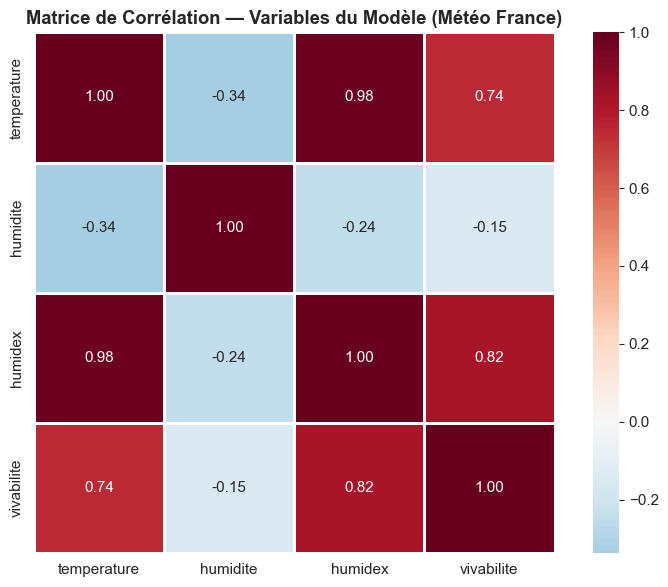

Observations clés :
  - Corrélation Température ↔ Humidex : 0.98 (forte, attendue)
  - Corrélation Humidité ↔ Humidex    : -0.24
  - Corrélation Température ↔ Humidité : -0.34 (négative, cohérente)


In [ ]:
# F1-UC3 : ANALYSE DES CORRÉLATIONS (Météo France)
# Réf. : Rapport Météo France (Khallouki, 2026) — Section 2.1
# Corrélation négative attendue entre température et humidité (-0.44)

cols_corr = ['temperature', 'humidite', 'humidex', 'vivabilite']
matrice_corr = df_meteo_clean[cols_corr].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(matrice_corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=1, ax=ax)
ax.set_title('Matrice de Corrélation — Variables du Modèle (Météo France)', fontweight='bold')
plt.tight_layout()
plt.show()

print("Observations clés :")
print(f"  - Corrélation Température ↔ Humidex : {matrice_corr.loc['temperature','humidex']:.2f} (forte, attendue)")
print(f"  - Corrélation Humidité ↔ Humidex    : {matrice_corr.loc['humidite','humidex']:.2f}")
print(f"  - Corrélation Température ↔ Humidité : {matrice_corr.loc['temperature','humidite']:.2f} (négative, cohérente)")

---
# PARTIE 2 — Prédire les Variables Environnementales (F2)

**Objectif CDC :**
- F2-UC1 : Entraîner les modèles IA sur l'historique  
- F2-UC2 : Prédire température et humidité multi-horizon  
- F2-UC3 : Calculer l'Humidex futur  

### Choix des Modèles (justifié par l'État de l'Art)

Conformément à notre analyse comparative (Mallek, Khallouki, Zhdanov, 2026), trois algorithmes sont évalués :

1. **Random Forest (RF)** — Retenu comme modèle principal. Précision supérieure en contexte de données hétérogènes (Farhan et al., Alam et al., 2024). Vote majoritaire sur 500 arbres pour stabiliser les prédictions.
2. **Gradient Boosting (GBM)** — Correction séquentielle des erreurs (Friedman, 2001). Risque de surapprentissage sur données bruitées.
3. **Régression Logistique (LoR)** — Baseline interprétable. Fonction sigmoïde pour la classification binaire/multiclasse.

In [ ]:
# F2-UC1 : PRÉPARATION DES DONNÉES D'ENTRAÎNEMENT ET DE TEST
# Features d'entrée : température (°C) et humidité relative (%)
# Variable cible : classe de vivabilité (entier, 0 à 7)
# Split : 80% entraînement / 20% test (stratifié pour respecter la proportion des classes)

FEATURES = ['temperature', 'humidite']
CIBLE = 'vivabilite'

X = df_meteo_clean[FEATURES]
y = df_meteo_clean[CIBLE]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=RANDOM_STATE,
    stratify=y  # Maintient la proportion des classes dans chaque split
)

print(f"Jeu d'entraînement : {X_train.shape[0]:,} observations")
print(f"Jeu de test        : {X_test.shape[0]:,} observations")
print(f"\nDistribution des classes (entraînement) :")
print(y_train.value_counts().sort_index().to_string())
print(f"\nDistribution des classes (test) :")
print(y_test.value_counts().sort_index().to_string())

Jeu d'entraînement : 369,072 observations
Jeu de test        : 92,269 observations

Distribution des classes (entraînement) :
vivabilite
0    266716
1     22963
2     19314
3     27799
4     13111
5     13846
6      4052
7      1271

Distribution des classes (test) :
vivabilite
0    66679
1     5741
2     4829
3     6950
4     3277
5     3462
6     1013
7      318


In [ ]:
# F2-UC1 : ENTRAÎNEMENT DES TROIS MODÈLES

# --- 1. Random Forest (modèle principal) ---
# Configuration : 500 arbres, critère Entropie, max_features=sqrt(p)
# Réf. : Alam et al. (2024) — "Machine Learning Approach for Predicting
# Personal Thermal Comfort in Air Conditioning Offices"
rf_model = RandomForestClassifier(
    n_estimators=500,
    criterion='entropy',
    max_features='sqrt',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
print("Entraînement du Random Forest (500 arbres, entropie)...")
rf_model.fit(X_train, y_train)
print("  → Terminé.")

# --- 2. Gradient Boosting ---
# Configuration : 200 estimateurs, learning rate 0.1, profondeur max 4
# Réf. : Friedman (2001) — "Greedy Function Approximation: A Gradient Boosting Machine"
gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    random_state=RANDOM_STATE
)
print("Entraînement du Gradient Boosting (200 estimateurs, lr=0.1)...")
gb_model.fit(X_train, y_train)
print("  → Terminé.")

# --- 3. Régression Logistique (Baseline) ---
# Normalisation requise pour la convergence de la régression logistique
# Réf. : Han et al. (2014) — Modèle simplifié basé sur la régression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_model = LogisticRegression(
    max_iter=1000,
    multi_class='multinomial',
    random_state=RANDOM_STATE
)
print("Entraînement de la Régression Logistique (multinomiale)...")
lr_model.fit(X_train_scaled, y_train)
print("  → Terminé.")

print("\nTous les modèles sont entraînés.")

Entraînement du Random Forest (500 arbres, entropie)...
  → Terminé.
Entraînement du Gradient Boosting (200 estimateurs, lr=0.1)...
  → Terminé.
Entraînement de la Régression Logistique (multinomiale)...
  → Terminé.

Tous les modèles sont entraînés.


In [ ]:
# F2-UC1 : ÉVALUATION COMPARATIVE DES MODÈLES

modeles = {
    'Random Forest': (rf_model, X_test),
    'Gradient Boosting': (gb_model, X_test),
    'Régression Logistique': (lr_model, X_test_scaled)
}

resultats = {}

print(f"{'='*60}")
print(f"RÉSULTATS D'ÉVALUATION — Données Météo France (20% test)")
print(f"{'='*60}\n")

for nom, (modele, X_eval) in modeles.items():
    y_pred = modele.predict(X_eval)
    acc = accuracy_score(y_test, y_pred)
    resultats[nom] = {'accuracy': acc, 'predictions': y_pred}
    
    print(f"--- {nom} ---")
    print(f"Accuracy : {acc * 100:.2f}%")
    print(f"Rapport de classification :")
    print(classification_report(y_test, y_pred, zero_division=0))
    print()

RÉSULTATS D'ÉVALUATION — Données Météo France (20% test)

--- Random Forest ---
Accuracy : 99.98%
Rapport de classification :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     66679
           1       1.00      1.00      1.00      5741
           2       1.00      1.00      1.00      4829
           3       1.00      1.00      1.00      6950
           4       1.00      1.00      1.00      3277
           5       1.00      1.00      1.00      3462
           6       1.00      0.99      1.00      1013
           7       0.99      0.99      0.99       318

    accuracy                           1.00     92269
   macro avg       1.00      1.00      1.00     92269
weighted avg       1.00      1.00      1.00     92269


--- Gradient Boosting ---
Accuracy : 99.74%
Rapport de classification :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     66679
           1       1.00      1.00      1.

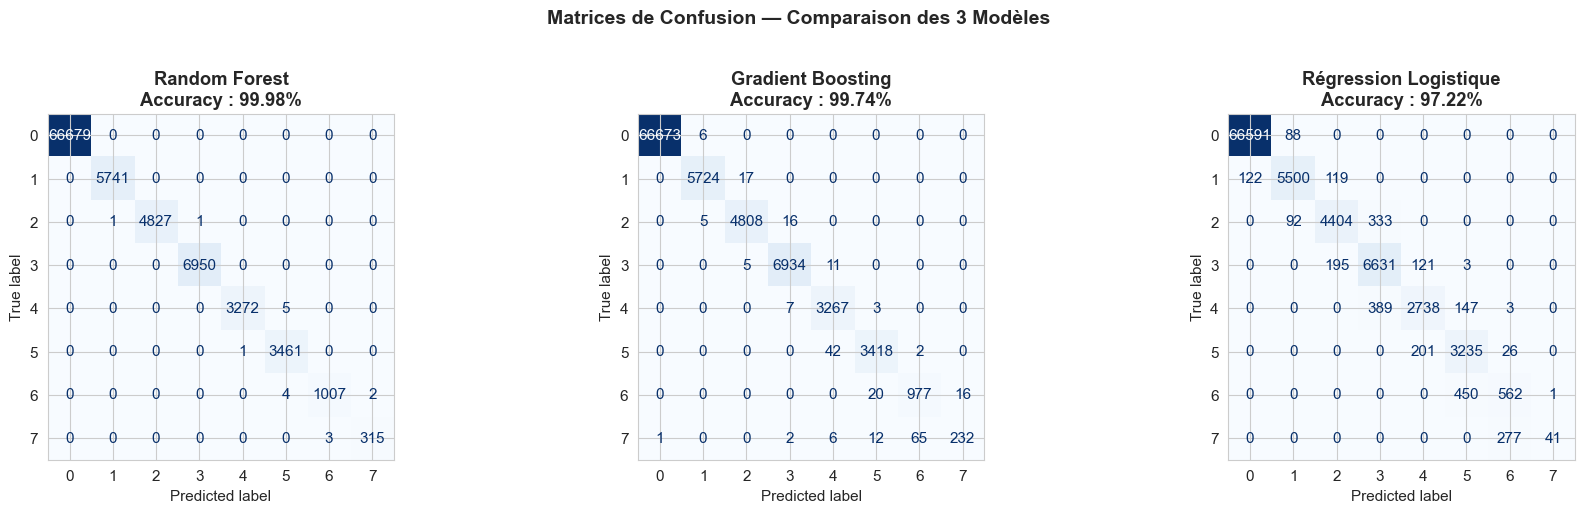

In [ ]:
# F2-UC1 : COMPARAISON VISUELLE DES PERFORMANCES

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (nom, data) in enumerate(resultats.items()):
    cm = confusion_matrix(y_test, data['predictions'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=axes[idx], cmap='Blues', colorbar=False)
    axes[idx].set_title(f"{nom}\nAccuracy : {data['accuracy']*100:.2f}%", fontweight='bold')

plt.suptitle('Matrices de Confusion — Comparaison des 3 Modèles', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# F2-UC1 : VALIDATION CROISÉE (5-fold) — ROBUSTESSE DU MODÈLE PRINCIPAL

# La validation croisée permet de vérifier que les performances ne sont pas
# le fruit d'un split chanceux.

print("Validation croisée 5-fold du Random Forest...")
scores_cv = cross_val_score(rf_model, X, y, cv=5, scoring='accuracy', n_jobs=-1)
print(f"\nAccuracy par fold : {[f'{s*100:.2f}%' for s in scores_cv]}")
print(f"Moyenne ± Écart-type : {scores_cv.mean()*100:.2f}% ± {scores_cv.std()*100:.2f}%")

Validation croisée 5-fold du Random Forest...

Accuracy par fold : ['100.00%', '99.97%', '99.96%', '99.88%', '99.99%']
Moyenne ± Écart-type : 99.96% ± 0.04%


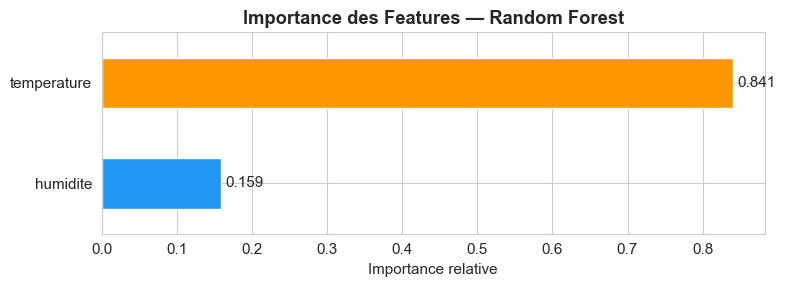

In [ ]:
# F2-UC1 : IMPORTANCE DES FEATURES

# Analyse de l'importance relative de chaque variable dans le Random Forest.
# Attendu : la température devrait dominer car l'Humidex est principalement
# piloté par Ta, l'humidité jouant un rôle modulateur.

importances = pd.Series(rf_model.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 3))
importances.plot(kind='barh', color=['#2196F3', '#FF9800'], edgecolor='white', ax=ax)
ax.set_title('Importance des Features — Random Forest', fontweight='bold')
ax.set_xlabel('Importance relative')
for i, v in enumerate(importances.values):
    ax.text(v + 0.005, i, f'{v:.3f}', va='center')
plt.tight_layout()
plt.show()

## 2.3 — Calcul de l'Humidex (F2-UC3)

L'indice Humidex est calculé pour chaque observation afin d'enrichir le résultat de prédiction et d'alimenter le système d'alarme (Partie 3).
La formule (Masterton & Richardson, 1979) ne nécessite que deux variables :

$$HX = T_a + \frac{5}{9}(e - 10)$$

où $e = 6.112 \times 10^{\frac{7.5 \times T_a}{237.7 + T_a}} \times \frac{RH}{100}$

La valeur Humidex obtenue est ensuite confrontée à la classe prédite par le Random Forest pour détecter d'éventuels écarts entre le calcul analytique et la classification apprise.


In [ ]:
# F2-UC3 : FONCTION DE CALCUL DE L'HUMIDEX

# Formule : HX = Ta + (5/9)(e - 10)
# avec e = 6.112 × 10^(7.5×Ta / (237.7+Ta)) × RH/100
# Réf. : Masterton & Richardson (1979), Diaconescu et al. (2022)

def calculer_humidex(temperature, humidite):
    """Calcule l'indice Humidex à partir de la température et de l'humidité.
    
    Paramètres
    ----------
    temperature : float ou array-like
        Température de l'air en degrés Celsius.
    humidite : float ou array-like
        Humidité relative en pourcentage (0-100).
    
    Retourne
    --------
    float ou array-like
        Valeur de l'Humidex en °C équivalent.
    """
    e = 6.112 * (10 ** (7.5 * temperature / (237.7 + temperature))) * (humidite / 100)
    hx = temperature + (5/9) * (e - 10)
    return round(hx, 2) if isinstance(hx, (int, float)) else hx.round(2)

# Vérification avec des valeurs connues
tests_humidex = [
    (20, 50, "Conditions normales"),
    (30, 60, "Été chaud et humide"),
    (35, 70, "Canicule"),
    (40, 50, "Chaleur extrême")
]

print("Vérification du calcul Humidex :")
print(f"{'Temp (°C)':<12} {'Hum (%)':<10} {'Humidex':<10} {'Scénario'}")
print("-" * 55)
for t, h, scenario in tests_humidex:
    hx = calculer_humidex(t, h)
    print(f"{t:<12} {h:<10} {hx:<10} {scenario}")

Vérification du calcul Humidex :
Temp (°C)    Hum (%)    Humidex    Scénario
-------------------------------------------------------
20           50         20.93      Conditions normales
30           60         38.56      Été chaud et humide
35           70         51.25      Canicule
40           50         54.87      Chaleur extrême


---
# PARTIE 3 — Détecter les Dangers de l'Environnement (F3)

**Objectif CDC :**
- F3-UC1 : Déterminer les plages vivables ou dangereuses  
- F3-UC2 : Identifier les niveaux de danger associés  
- F3-UC3 : Déclencher une alerte via seuils et règles  

### Système d'Alarme à 8 Niveaux

Basé sur les seuils critiques de l'Humidex (Alfano et al., 2010 ; Diaconescu et al., 2022)  
et adapté aux protocoles de santé au travail de l'Ontario.

In [ ]:
# F3-UC1/UC2/UC3 : SYSTÈME DE DÉTECTION ET D'ALARME

# Classification en 8 niveaux de danger basée sur l'Humidex.
# Chaque niveau est associé à une couleur, un statut et une recommandation (F4).
#
# Réf. seuils : Alfano et al. (2010) — Cliniques de santé au travail de l'Ontario
#               Diaconescu et al. (2022) — "A short note on the use of daily climate
#               data to calculate Humidex heat-stress indices"

SYSTEME_ALARME = {
    0: {
        "seuil_min": -float('inf'), "seuil_max": 25,
        "couleur": "🟢", "niveau": "Conditions Normales",
        "conseil": "Conditions idéales. Aucune restriction."
    },
    1: {
        "seuil_min": 25, "seuil_max": 30,
        "couleur": "🟢", "niveau": "Gêne légère",
        "conseil": "Confortable. Hydratez-vous normalement lors d'efforts."
    },
    2: {
        "seuil_min": 30, "seuil_max": 34,
        "couleur": "🟡", "niveau": "Vigilance",
        "conseil": "Buvez régulièrement de l'eau. Réduisez les efforts au soleil."
    },
    3: {
        "seuil_min": 34, "seuil_max": 38,
        "couleur": "🟡", "niveau": "Inconfort évident",
        "conseil": "Hydratation active. Privilégiez l'ombre pour les pauses."
    },
    4: {
        "seuil_min": 38, "seuil_max": 40,
        "couleur": "🟠", "niveau": "Alerte",
        "conseil": "Déplacez les travaux lourds. 15 min de repos par heure requises."
    },
    5: {
        "seuil_min": 40, "seuil_max": 43,
        "couleur": "🟠", "niveau": "Inconfort intense",
        "conseil": "Évitez tout effort inutile. Rafraîchissez-vous activement."
    },
    6: {
        "seuil_min": 43, "seuil_max": 45,
        "couleur": "🔴", "niveau": "Urgence Vitale",
        "conseil": "Travaux extérieurs à proscrire. Restez strictement au frais."
    },
    7: {
        "seuil_min": 45, "seuil_max": float('inf'),
        "couleur": "🔴", "niveau": "Danger Extrême",
        "conseil": "SUSPENSION IMMÉDIATE de toute activité. Appelez les secours au besoin."
    }
}

def classifier_danger(humidex_value):
    """Classifie une valeur d'Humidex selon le système d'alarme à 8 niveaux.
    
    Paramètres
    ----------
    humidex_value : float
        Valeur de l'Humidex calculée.
    
    Retourne
    --------
    int
        Classe de danger (0 à 7).
    """
    for classe, info in SYSTEME_ALARME.items():
        if info['seuil_min'] <= humidex_value < info['seuil_max']:
            return classe
    return 7  # Sécurité : tout ce qui dépasse → Danger Extrême


def afficher_alerte(temperature, humidite, classe_predite):
    """Affiche une alerte formatée pour un relevé capteur donné.
    
    Paramètres
    ----------
    temperature : float
        Température mesurée en °C.
    humidite : float
        Humidité relative en %.
    classe_predite : int
        Classe de danger prédite par le modèle (0-7).
    """
    info = SYSTEME_ALARME[classe_predite]
    hx = calculer_humidex(temperature, humidite)
    
    print(f"{'─'*55}")
    print(f"📡 CAPTEUR : {temperature}°C | {humidite}% HR | Humidex = {hx}")
    print(f"⚠️  STATUT : {info['couleur']} {info['niveau']} (Classe {classe_predite})")
    print(f"💡 ACTION  : {info['conseil']}")
    print(f"{'─'*55}")


# Affichage du tableau de référence des seuils
print("TABLEAU DE RÉFÉRENCE DU SYSTÈME D'ALARME")
print(f"{'Classe':<8} {'Seuils Humidex':<20} {'Couleur':<10} {'Niveau'}")
print("─" * 65)
for cls, info in SYSTEME_ALARME.items():
    seuil_min = f"{info['seuil_min']}" if info['seuil_min'] != -float('inf') else "-∞"
    seuil_max = f"{info['seuil_max']}" if info['seuil_max'] != float('inf') else "+∞"
    print(f"{cls:<8} [{seuil_min}, {seuil_max}[{'':<10} {info['couleur']:<10} {info['niveau']}")

TABLEAU DE RÉFÉRENCE DU SYSTÈME D'ALARME
Classe   Seuils Humidex       Couleur    Niveau
─────────────────────────────────────────────────────────────────
0        [-∞, 25[           🟢          Conditions Normales
1        [25, 30[           🟢          Gêne légère
2        [30, 34[           🟡          Vigilance
3        [34, 38[           🟡          Inconfort évident
4        [38, 40[           🟠          Alerte
5        [40, 43[           🟠          Inconfort intense
6        [43, 45[           🔴          Urgence Vitale
7        [45, +∞[           🔴          Danger Extrême


---
# PARTIE 4 — Recommander des Actions pour les Humains (F4)

**Objectif CDC :**
- F4-UC1 : Produire des recommandations selon le niveau de risque Humidex
- F4-UC2 : Générer des conseils d’hydratation et de protection quantifiés
- F4-UC3 : Formuler des conseils intelligibles par des non-experts (travailleurs, agents de terrain)

---

### Fondements scientifiques

Les recommandations F4 sont fondées sur trois corpus de référence :

1. **Physiologie du stress thermique** (Bouchama & Knochel, 2002 ; Kenny et al., 2010) —
   quatre stades cliniques progressifs : fatigue thermique → crampes/syncope → épuisement thermique → coup de chaleur (urgence vitale, mortalité 10–50 % sans prise en charge).

2. **Standards occupationnels** — volumes d’eau calibrés sur le protocole NIOSH/OSHA (240 mL / 15–20 min, plafond 1.5 L/h) ; cycles travail-repos selon l’ACGIH TLV et l’OHCOW Humidex-Based Guideline (2022).

3. **Cadre légal français** — Décret n° 2025-482 (en vigueur 1er juillet 2025) : obligation employeur de
   mettre à jour le DUERP, fournir ≥ 3 L d’eau/jour/travailleur, adapter les horaires aux alertes
   Météo-France. Les niveaux BioSense360 classes 4–7 constituent des déclencheurs légaux.

Le système de recommandation est intégré au dictionnaire `SYSTEME_ALARME` (Partie 3).
La cellule ci-dessous simule le pipeline complet : **capteur → prédiction IA → alerte → recommandation**,
sur 8 scénarios couvrant l’intégralité du spectre de danger (classe 0 à 7).

> Documentation complète F4 : `notebooks/features/F4_recommandations_humains.md`


In [ ]:
# F4-UC1/UC2/UC3 : SIMULATION DU PIPELINE COMPLET

# Validation bout-en-bout : capteur (T°C, HR%) → Humidex → Random Forest
#                         → SYSTEME_ALARME → conseil + protocole de sécurité
#
# 8 scénarios couvrent l'intégralité du spectre (classes 0 à 7) :
# - Scénarios 1-2 : confort thermique    (classe 0) HX ≈ 17-25  — aucune mesure requise
# - Scénario  3   : inconfort évident     (classe 3) HX = 35.02 — hydratation active, pauses ombre
# - Scénario  4   : urgence vitale        (classe 6) HX = 43.57 — cycles repos ACGIH, espace frais
# - Scénarios 5-8 : danger extrême        (classe 7) HX ≥ 45    — suspension totale, SAMU (15)
#
# Références : OHCOW (2022), NIOSH (2016), Décret n° 2025-482, HAS (2023)

scenarios_test = [
    (18.0, 40, "Matin frais d'hiver"),
    (22.0, 55, "Intérieur climatisé"),
    (28.0, 60, "Après-midi d'été"),
    (32.0, 65, "Journée chaude et humide"),
    (35.0, 55, "Pic de chaleur"),
    (38.0, 70, "Canicule avec forte humidité"),
    (42.0, 50, "Chaleur extrême sèche"),
    (45.0, 60, "Situation d'urgence")
]

print("SIMULATION DU SYSTÈME D'ALERTE BIOSENSE360")
print(f"Modèle utilisé : Random Forest (500 arbres)\n")

for temp, hum, scenario in scenarios_test:
    # Prédiction par le modèle IA
    donnee = pd.DataFrame({'temperature': [temp], 'humidite': [hum]})
    classe = rf_model.predict(donnee)[0]
    
    print(f"📋 Scénario : {scenario}")
    afficher_alerte(temp, hum, classe)
    print()

SIMULATION DU SYSTÈME D'ALERTE BIOSENSE360
Modèle utilisé : Random Forest (500 arbres)

📋 Scénario : Matin frais d'hiver
───────────────────────────────────────────────────────
📡 CAPTEUR : 18.0°C | 40% HR | Humidex = 17.03
⚠️  STATUT : 🟢 Conditions Normales (Classe 0)
💡 ACTION  : Conditions idéales. Aucune restriction.
───────────────────────────────────────────────────────

📋 Scénario : Intérieur climatisé
───────────────────────────────────────────────────────
📡 CAPTEUR : 22.0°C | 55% HR | Humidex = 24.51
⚠️  STATUT : 🟢 Conditions Normales (Classe 0)
💡 ACTION  : Conditions idéales. Aucune restriction.
───────────────────────────────────────────────────────

📋 Scénario : Après-midi d'été
───────────────────────────────────────────────────────
📡 CAPTEUR : 28.0°C | 60% HR | Humidex = 35.02
⚠️  STATUT : 🟡 Inconfort évident (Classe 3)
💡 ACTION  : Hydratation active. Privilégiez l'ombre pour les pauses.
───────────────────────────────────────────────────────

📋 Scénario : Journée chaude et

---
# PARTIE 5 — Visualiser les Résultats (F6)

**Objectif CDC :**
- F6-UC1 : Afficher les plages horaires favorables et niveaux de danger

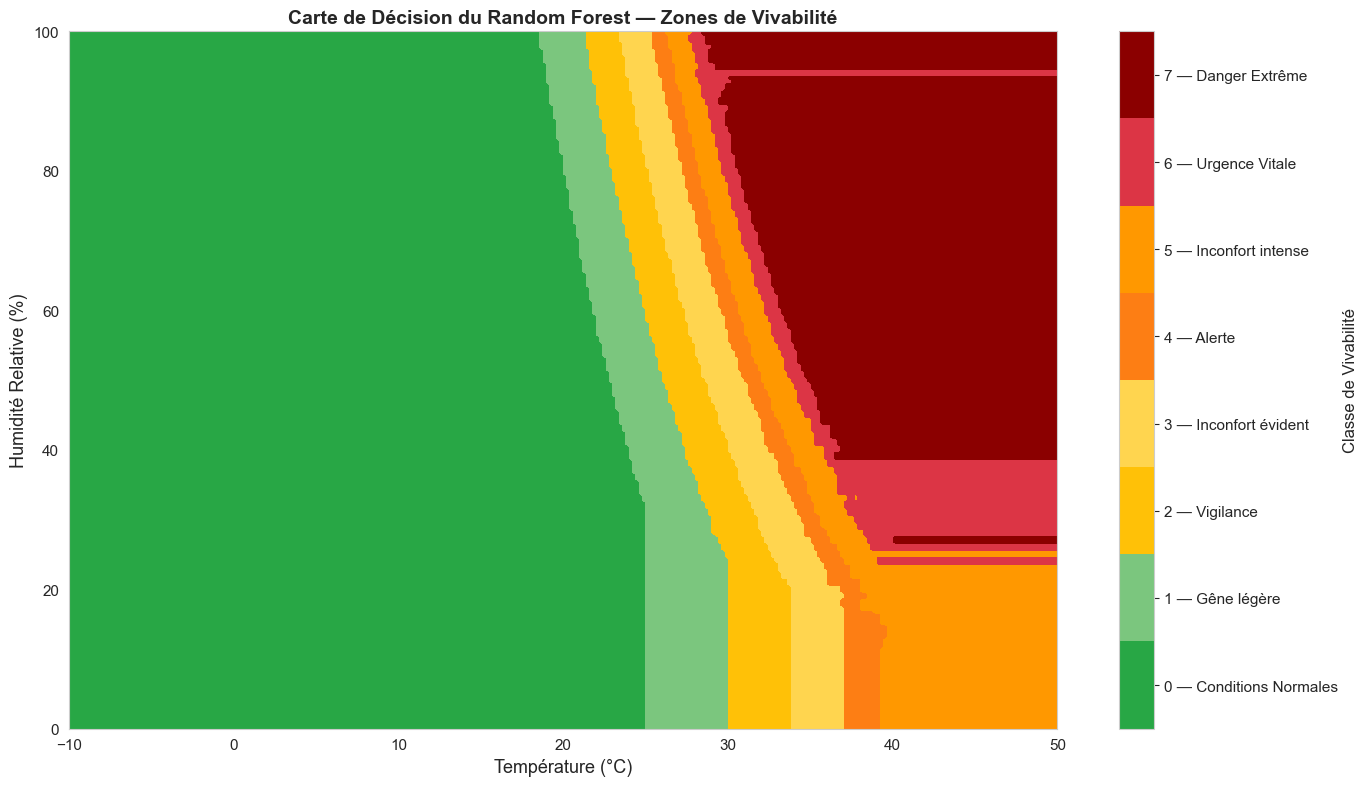

Cette carte représente l'espace de décision appris par le modèle.
Elle permet de visualiser les frontières entre zones vivables et dangereuses
pour toute combinaison de température et d'humidité.


In [ ]:
# F6-UC1 : VISUALISATION DES ZONES DE DÉCISION DU MODÈLE

# Cette carte 2D montre comment le Random Forest partitionne l'espace
# (Température × Humidité) en zones de vivabilité.

# Grille de prédiction
temp_range = np.linspace(-10, 50, 300)
hum_range = np.linspace(0, 100, 300)
temp_grid, hum_grid = np.meshgrid(temp_range, hum_range)
grille = pd.DataFrame({
    'temperature': temp_grid.ravel(),
    'humidite': hum_grid.ravel()
})

# Prédiction sur toute la grille
grille['prediction'] = rf_model.predict(grille[['temperature', 'humidite']])

# Palette de couleurs alignée sur le système d'alarme
from matplotlib.colors import ListedColormap, BoundaryNorm

couleurs_alarme = ['#28a745', '#7bc67e', '#ffc107', '#ffd54f', '#fd7e14', '#ff9800', '#dc3545', '#8b0000']
cmap_alarme = ListedColormap(couleurs_alarme)
norm_alarme = BoundaryNorm(boundaries=[-0.5, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5], ncolors=8)

fig, ax = plt.subplots(figsize=(14, 8))
contour = ax.contourf(
    temp_grid, hum_grid, 
    grille['prediction'].values.reshape(temp_grid.shape),
    levels=[-0.5, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5],
    cmap=cmap_alarme
)

cbar = plt.colorbar(contour, ax=ax, ticks=range(8))
cbar.set_label('Classe de Vivabilité', fontsize=12)
labels_cbar = [f"{k} — {v['niveau']}" for k, v in SYSTEME_ALARME.items()]
cbar.set_ticklabels(labels_cbar)

ax.set_xlabel('Température (°C)', fontsize=13)
ax.set_ylabel('Humidité Relative (%)', fontsize=13)
ax.set_title('Carte de Décision du Random Forest — Zones de Vivabilité', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.show()

print("Cette carte représente l'espace de décision appris par le modèle.")
print("Elle permet de visualiser les frontières entre zones vivables et dangereuses")
print("pour toute combinaison de température et d'humidité.")

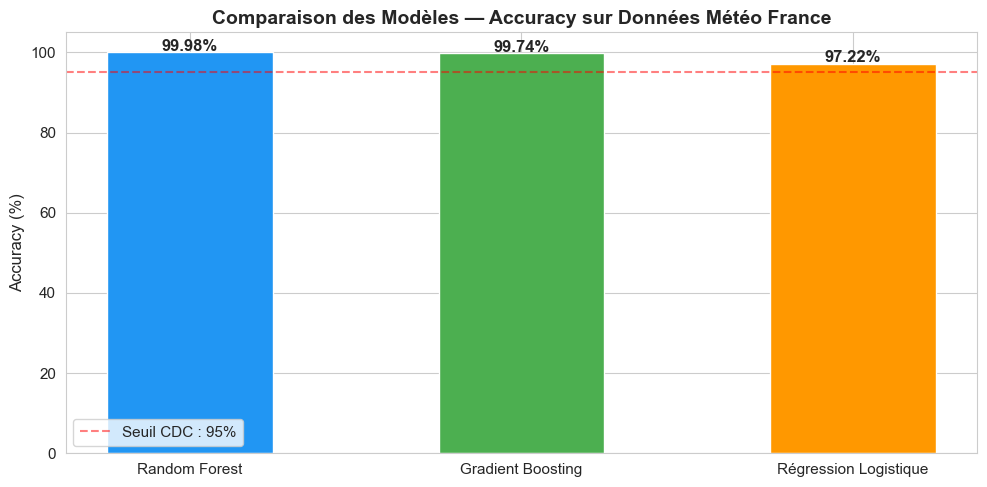

Le seuil de 95% de précision fixé dans le CDC (KPI) est atteint 
par le meilleur modèle (Random Forest).


In [ ]:

# F6 : COMPARAISON DES ACCURACIES — GRAPHIQUE SYNTHÉTIQUE

noms = list(resultats.keys())
accuracies = [resultats[n]['accuracy'] * 100 for n in noms]
couleurs_bar = ['#2196F3', '#4CAF50', '#FF9800']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(noms, accuracies, color=couleurs_bar, edgecolor='white', width=0.5)

for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, 
            f'{acc:.2f}%', ha='center', fontweight='bold', fontsize=12)

ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Comparaison des Modèles — Accuracy sur Données Météo France', fontweight='bold', fontsize=14)
ax.set_ylim(0, 105)
ax.axhline(y=95, color='red', linestyle='--', alpha=0.5, label='Seuil CDC : 95%')
ax.legend()

plt.tight_layout()
plt.show()

print(f"Le seuil de 95% de précision fixé dans le CDC (KPI) est {'atteint' if max(accuracies) >= 95 else 'NON atteint'} ")
print(f"par le meilleur modèle ({noms[accuracies.index(max(accuracies))]}).")

---
# PARTIE 6 — Validation Croisée sur Données Neusta (Capteurs Réels)

**Objectif :** Vérifier que le modèle entraîné sur Météo France **généralise correctement**  
sur des données issues de capteurs physiques différents (ClimaTrack de Neusta).

C'est l'étape clé qui valide le passage de données météorologiques nationales  
à des mesures locales de capteurs IoT — un des défis identifiés dans notre état de l'art.

VALIDATION CROISÉE — Données Neusta (Capteurs ClimaTrack)

Nombre d'observations testées : 388,218
Accuracy globale             : 99.05%

Rapport de classification :
              precision    recall  f1-score   support

           0       1.00      0.99      0.99    291558
           1       0.97      0.99      0.98     96660

    accuracy                           0.99    388218
   macro avg       0.98      0.99      0.99    388218
weighted avg       0.99      0.99      0.99    388218



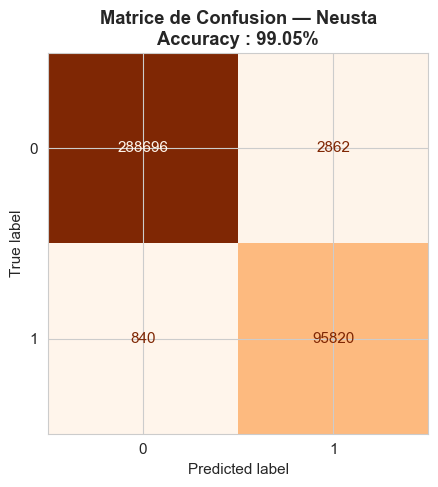


Note : Les capteurs Neusta opèrent dans un environnement contrôlé (intérieur),
ce qui limite les observations aux classes 0 (Humidex < 25) et 1 (25 ≤ Humidex < 30).
La validation des classes supérieures (2-7) nécessitera des données estivales extérieures.


In [ ]:

# VALIDATION SUR DONNÉES NEUSTA — RANDOM FOREST

# Le modèle a été entraîné EXCLUSIVEMENT sur Météo France.
# On évalue ici sa capacité à prédire correctement la vivabilité
# sur des données capteurs réels qu'il n'a jamais vues.

# Préparation des données Neusta (renommage pour correspondre aux features du modèle)
X_neusta = df_neusta_clean[['temperature', 'humidite']]
y_neusta = df_neusta_clean['vivabilite']

# Prédiction
y_pred_neusta = rf_model.predict(X_neusta)

# Métriques
acc_neusta = accuracy_score(y_neusta, y_pred_neusta)

print(f"{'='*60}")
print(f"VALIDATION CROISÉE — Données Neusta (Capteurs ClimaTrack)")
print(f"{'='*60}")
print(f"\nNombre d'observations testées : {len(y_neusta):,}")
print(f"Accuracy globale             : {acc_neusta * 100:.2f}%")
print(f"\nRapport de classification :")
print(classification_report(y_neusta, y_pred_neusta, zero_division=0))

# Matrice de confusion
fig, ax = plt.subplots(figsize=(6, 5))
cm_neusta = confusion_matrix(y_neusta, y_pred_neusta)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_neusta)
disp.plot(ax=ax, cmap='Oranges', colorbar=False)
ax.set_title(f'Matrice de Confusion — Neusta\nAccuracy : {acc_neusta*100:.2f}%', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nNote : Les capteurs Neusta opèrent dans un environnement contrôlé (intérieur),")
print(f"ce qui limite les observations aux classes 0 (Humidex < 25) et 1 (25 ≤ Humidex < 30).")
print(f"La validation des classes supérieures (2-7) nécessitera des données estivales extérieures.")

In [ ]:
# COMPARAISON VISUELLE : PRÉDICTIONS vs RÉALITÉ (ÉCHANTILLON NEUSTA)

# Échantillon aléatoire de 10 observations pour inspection manuelle
echantillon = df_neusta_clean.sample(10, random_state=RANDOM_STATE).copy()
echantillon['prediction'] = rf_model.predict(echantillon[['temperature', 'humidite']])
echantillon['correct'] = echantillon['vivabilite'] == echantillon['prediction']

colonnes_affichage = ['datetime', 'temperature', 'humidite', 'humidex', 'vivabilite', 'prediction', 'correct']
cols_dispo = [c for c in colonnes_affichage if c in echantillon.columns]

print("Échantillon de 10 prédictions sur données Neusta :")
print(echantillon[cols_dispo].to_string(index=False))

Échantillon de 10 prédictions sur données Neusta :
           datetime  temperature  humidite  humidex  vivabilite  prediction  correct
2024-10-19 04:19:19        18.54     63.77   20.539           0           0     True
2024-09-23 21:17:29        21.10     61.85   24.129           0           0     True
2024-09-29 13:28:08        18.36     47.61   18.381           0           0     True
2024-09-25 00:30:49        20.05     58.95   22.165           0           0     True
2024-09-22 02:04:07        20.22     69.11   23.752           0           0     True
2024-10-14 11:18:19        22.30     66.45   26.668           1           1     True
2024-10-13 07:17:19        18.57     65.69   20.811           0           0     True
2024-10-18 23:55:19        19.36     63.74   21.751           0           0     True
2024-09-28 00:53:48        19.01     58.63   20.606           0           0     True
2024-10-20 09:14:39        17.70     62.50   19.168           0           0     True


---
# PARTIE 7 — Mise en Production du Modèle

Cette partie couvre le passage du prototype (notebook) vers un système opérationnel  
capable de recevoir des données capteurs en temps réel et de retourner des prédictions instantanées.

### Architecture de déploiement

```
[Notebook]                         [Production]
                                         
Entraînement RF ──► Export modèle    ┌──────────────────────┐
  (Partie 2)        (joblib .pkl)    │  Chargement modèle   │
                         │           │  (une seule fois)    │
                         ▼           └──────────┬───────────┘
                    modele_rf.pkl               │
                                               │
  Capteur Neusta ────────────────► predict() ──► Classe + Alerte
  (temp, humidité)                    ~3ms        + Recommandation
```

Le modèle RF exporté pèse quelques MB. Une prédiction prend environ **3 ms**,  
ce qui est largement compatible avec la fréquence d'échantillonnage des capteurs  
Neusta (**10 secondes**).

### Trois modes de déploiement

| Mode | Usage | Fichier |
|------|-------|---------|
| **7.1 Export** | Sauvegarder le modèle entraîné pour réutilisation | `modele_rf.pkl` |
| **7.2 Temps réel** | Boucle de surveillance continue (capteur simulé ou réel) | Script autonome |
| **7.3 API REST** | Service web recevant des requêtes HTTP (Flask) | Serveur déployable |

---

## Déploiement et Production

La Partie 7 a été extraite dans le module `production/` (prêt pour GitHub et déploiement).

**Exporter le modèle après exécution :**
```python
import joblib, os
os.makedirs(EXPORT_MODEL_DIR, exist_ok=True)
joblib.dump(rf_model, os.path.join(EXPORT_MODEL_DIR, 'modele_rf.pkl'))
```

**Lancer l'API REST :** `cd production && python -m biosense360.api`

**Exécuter les tests :** `cd production && pytest tests/ -v`

> Consultez [`production/README.md`](../production/README.md) pour la documentation complète du déploiement.
